# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2023**


----

# Trabajo práctico entregable - parte 2


En el ejercicio 1 de la parte 1 del entregable seleccionaron las filas y columnas relevantes al problema de predicción de precios de una propiedad.
Además de ello, tuvieron que reducir el número de valores posibles para las variables categóricas utilizando información de dominio.
> No se encuentra esta consigna en el entregable 1 *(falta de comunicación entre las personas que se dividieron la confección de las consignas de este entregable)*

En el ejercicio 2 de la parte 1 del entregable imputaron los valores faltantes de las columnas `Suburb` y las columnas obtenidas a partir del conjunto de datos `airbnb`.
> No se encuentra esta consigna en el entregable 1 *(no hay items referidos a imputación)*,  *(falta de comunicación entre las personas que se dividieron la confección de las consignas de este entregable)*  

En esta notebook, **se utilizará resultado de dichas operaciones.**

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from pandas.api.types import CategoricalDtype
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

/home/ruben/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
FIGSIZE, VSUBPLOTS_FIGSIZE, HSUBPLOTS_FIGSIZE, DPI = (10, 5), (15, 10), (15, 5), 100
PASTEL_PALETTE = sns.color_palette('pastel')
MAIN_PALETTE = itertools.cycle(PASTEL_PALETTE)
CATEGORICAL_PALETTE = sns.color_palette('Set2')
SECUENTIAL_PALETTE = sns.color_palette('flare')

statistics_of_interest = ['mean', 'std', '25%', '50%', '75%']

In [3]:
def human_format(num, pos=1):
    """
    human formatting for big numbers
    """
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return "%.0f%s" % (num, ["", "K", "M", "G", "T", "P"][magnitude])


FORMATTER = FuncFormatter(human_format)

In [4]:
original_df = pd.read_csv('data/melbourne_housing_curated_data.csv')

In [5]:
original_df.sample(15).style.format(
    {'Price': human_format,
     'NeighborhoodOverview': lambda x: x[:50]},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingRatio'], color='brown')

,Address,Suburb,Rooms,Price,Type,Distance,Propertycount,Bedroom2,Car,BuildingArea,YearBuilt,Neighborhood,City,State,ZipCode,SmartLocation,NeighborhoodOverview,BuildingRatio
754,7 Louisa St,Brunswick,3,1M,h,5.2,11918,3,3,119.0,1943.0,Brunswick,Moreland,VIC,3056.0,"Brunswick, Australia",This hip area is a crossroads between two great cu,2.6
590,2/422 St Kilda St,Brighton,3,1M,t,11.2,10579,3,2,163.0,2000.0,Brighton,Bayside,VIC,3186.0,"Brighton, Australia",Very leafy very safe street 5 minute walk to 711 c,2.1
1728,40 Angus St,Hadfield,3,740K,h,12.1,2606,3,1,115.0,1960.0,Central Business District,Melbourne,VIC,3046.0,"Hadfield, Australia",The apartment is located in the centre of Melbourn,4.9
3090,199 Buckley St,Seddon,2,665K,h,6.6,2417,2,0,80.0,1900.0,Yarraville/Seddon,Maribyrnong,VIC,3011.0,"Seddon, Australia",The house is located in a quiet street in the hip,3.4
2952,9 Kelverne St,Reservoir,3,685K,h,12.0,21650,3,3,102.0,1960.0,Coburg,Darebin,VIC,3073.0,"Reservoir, Australia",The apartment is fully self contained and separate,4.8
552,80 South Rd,Braybrook,4,645K,h,10.8,3589,4,1,154.0,1990.0,Footscray,Maribyrnong,VIC,3019.0,"Braybrook, Australia",Seddon is a great place and growing by the minute,1.8
3676,57 Wales St,Kingsville,3,925K,h,7.8,1808,3,1,100.0,1920.0,Yarraville/Seddon,Maribyrnong,VIC,3012.0,"Kingsville, Australia",The house is located in a quiet street in the hip,2.8
1176,203 Munro St,Coburg,4,1M,h,7.8,11204,4,1,189.0,1970.0,Brunswick,Moreland,VIC,3058.0,"Coburg, Australia",This hip area is a crossroads between two great cu,4.5
2216,33 River St,Maribyrnong,4,1M,h,8.7,4918,4,4,142.0,1950.0,Footscray,Maribyrnong,VIC,3032.0,"Maribyrnong, Australia",Seddon is a great place and growing by the minute,4.3
3117,27 Lyell St,South Melbourne,3,2M,h,2.1,5943,3,1,105.0,1910.0,South Melbourne,Port Phillip,VIC,3205.0,"South Melbourne, Australia",Clarendon Street is a 5 minute walk and has someth,1.9


## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos obtenido en la parte 1 del entregable, **excepto** `BuildingArea` y `YearBuilt`, que volveremos a imputar más adelante.


### Columnas de interés

Se trabajó con un nuevo dataframe con aquellas columnas que no sean 'BuildingArea' ni 'YearBuilt'.

In [6]:
columns_of_interest = list(
    set(original_df.columns).difference(
        {'BuildingArea', 'YearBuilt'}
    )
)

In [7]:
df = original_df[columns_of_interest]

2. Aplicar una codificación One-hot encoding a cada fila, tanto para variables numéricas como categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas. 
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.

### Encoding

#### OneHot

Onehot enconding **no se aplica a variables numéricas:**
> Encode categorical features as a one-hot numeric array.
> The input to this transformer should be an array-like of integers or strings, denoting the values taken on by categorical (discrete) features. The features are encoded using a one-hot (aka ‘one-of-K’ or ‘dummy’) encoding scheme. This creates a binary column for each category and returns a sparse matrix or dense array (depending on the sparse_output parameter)

extraído de la documentación oficial de scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

> Falta de expertise de la docente que confeccionó la consigna

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3863 entries, 0 to 3862
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Propertycount         3863 non-null   int64  
 1   Type                  3863 non-null   object 
 2   NeighborhoodOverview  3863 non-null   object 
 3   Suburb                3863 non-null   object 
 4   Bedroom2              3863 non-null   int64  
 5   Distance              3863 non-null   float64
 6   Car                   3863 non-null   int64  
 7   Price                 3863 non-null   float64
 8   Rooms                 3863 non-null   int64  
 9   State                 3863 non-null   object 
 10  BuildingRatio         3863 non-null   float64
 11  Neighborhood          3863 non-null   object 
 12  ZipCode               3818 non-null   float64
 13  City                  3863 non-null   object 
 14  SmartLocation         3863 non-null   object 
 15  Address              

One-Hot Encoder se aplica como alternativa a label encoding, para evitar malas interpretaciones de variables numéricas. En este encoding **cada categoría** se convierte en una nueva columna a la que se le asigna `0` o `1` (notación del tipo true/false)

One-Hot encoding se aplica a *la única variable categórica*: `Type`, luego de asignarle a cada uno de los tipos un *label*:

In [9]:
labelencoder = LabelEncoder()  # label-encoder instance
df_encoding = pd.DataFrame()
df_encoding['Type_Labels'] = labelencoder.fit_transform(df['Type'])
df_encoding = df_encoding.join(df[['Type']])
df_encoding.sample(10)

# TODO agregar tabla resultante (de labels) a md

,Type_Labels,Type
1616,0,h
3213,2,u
817,2,u
2171,1,t
3305,0,h
188,0,h
2266,0,h
2375,1,t
1649,0,h
3182,0,h


In [10]:
one_hot_encoder = OneHotEncoder(handle_unknown='ignore')  # one-hot-encoder instance
one_hot_encoder_df = pd.DataFrame(one_hot_encoder.fit_transform(df_encoding[['Type_Labels']]).toarray())  # encode
one_hot_encoder_df = one_hot_encoder_df.astype(int)
one_hot_encoder_df.sample(15)

# TODO agregar tabla resultante (de encoding) a md

,0,1,2
2763,0,1,0
1587,0,0,1
1625,1,0,0
1533,1,0,0
2127,1,0,0
2426,1,0,0
2337,1,0,0
219,1,0,0
2514,1,0,0
2375,0,1,0


In [11]:
df_encoding.drop(columns=['Type_Labels'])
df_encoding = df_encoding.join(one_hot_encoder_df)

In [12]:
df_encoding

,Type_Labels,Type,0,1,2
0,0,h,1,0,0
1,0,h,1,0,0
2,0,h,1,0,0
3,0,h,1,0,0
4,0,h,1,0,0
...,...,...,...,...,...
3858,0,h,1,0,0
3859,0,h,1,0,0
3860,0,h,1,0,0
3861,0,h,1,0,0


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer` para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.
> ¿Cuáles *"ambos"* métodos? Se propone sólo uno...

In [13]:
df_encoding = df_encoding.join(original_df.YearBuilt)

In [14]:
X = df_encoding[['Type_Labels', 'YearBuilt']]  # training data (matrix)
y = df_encoding['YearBuilt']  # data to be estimated

X.sample(10)

,Type_Labels,YearBuilt
3700,0,1955.0
1928,0,1980.0
1382,0,1920.0
405,0,1965.0
146,0,1910.0
2533,0,1920.0
3310,0,1930.0
2361,0,1955.0
3833,1,2011.0
3166,0,1950.0


En el pre-procesamiento de datos se creó una nueva columna `BuildingRatio` a fin de unificar y simplificar la información de las columnas `BuildingArea` y `Landsize`, se imputan los valores faltantes de `YearBuilt` como sigue aplicando una instancia de `IterativeImputer` con diferentes estimadores, dado que la consigna no es clara y no se comprende a qué (*"¿ambos'"*) métodos se refiere.

- La matriz queda conformada por el resultado del encoding de `Type`: $\{0, 1, 2\}$
- así como el año de construcción de la propiedad:
    - formato numérico
    - datos discretos
    - en una escala consistente (*años*)
    
por lo que **no es necesario estandarizar ni escalar**

In [15]:
all_iterative_methods = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
}

imputed = {}

original_color = next(MAIN_PALETTE)
imputed_color = next(MAIN_PALETTE)

for method_name, method in all_iterative_methods.items():
    imputer = IterativeImputer(estimator=method)

    imputer.fit(X)  # fit the imputer on the training data

    X_imputed = imputer.transform(X)  # transform the dataset to impute the missing values
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)  # replace the imputed values in the DataFrame

    original_values = y.values
    imputed_values = X_imputed_df['YearBuilt'].values 

    imputed[method_name] = (original_values, imputed_values)

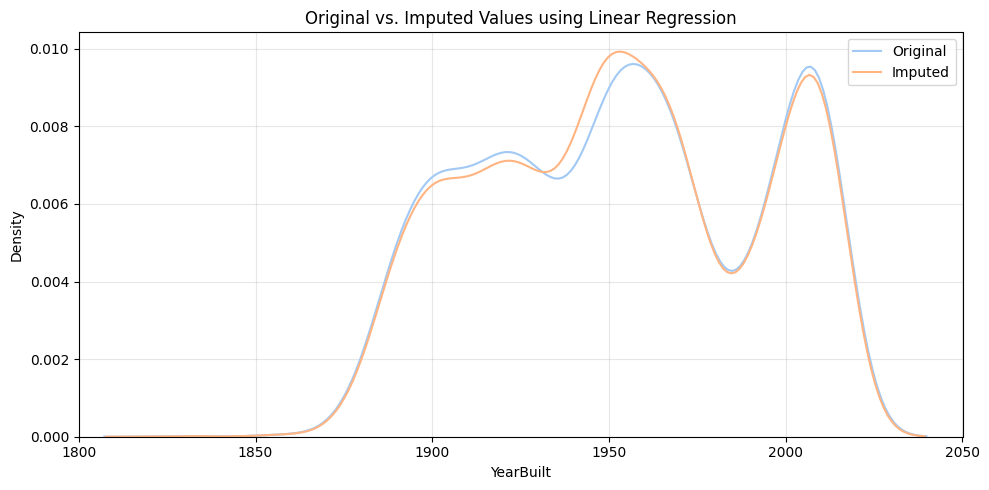

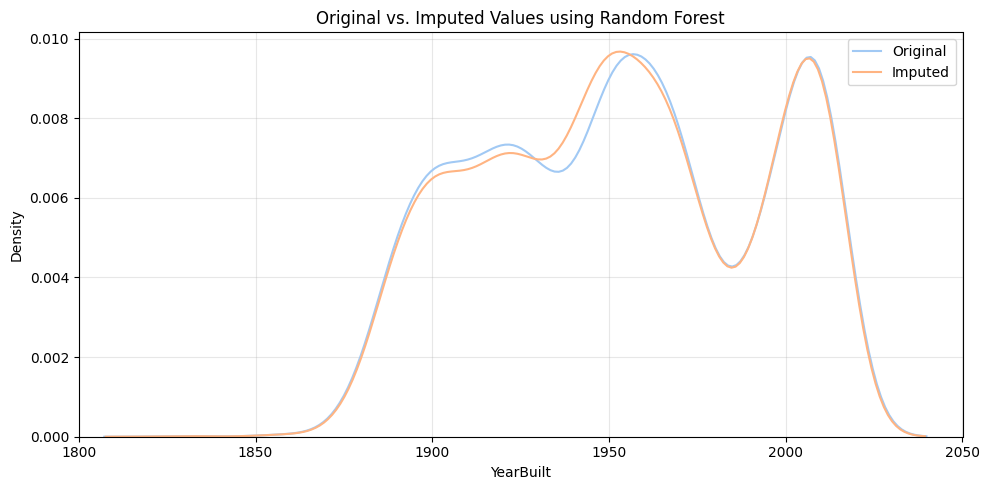

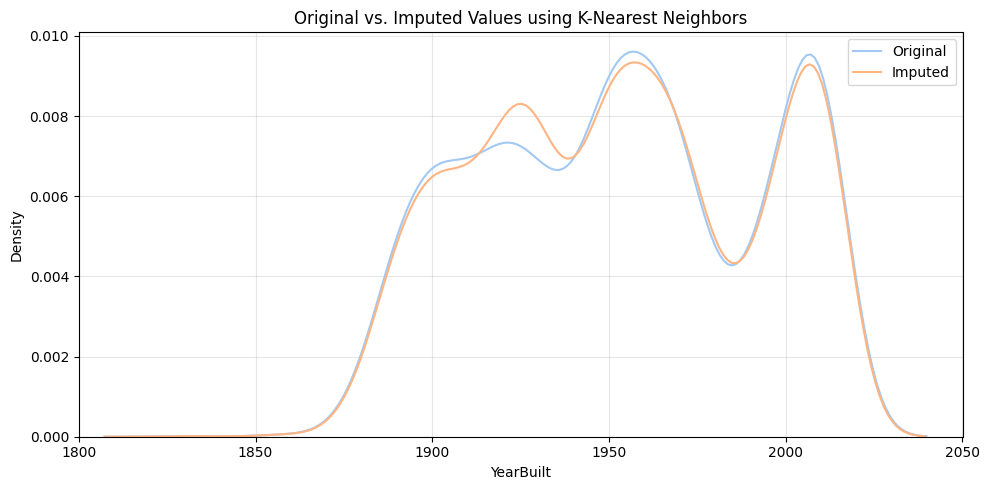

In [16]:
for method_name in imputed:
    (original_values, imputed_values) = imputed[method_name]
    
    plt.figure(figsize=FIGSIZE)
    sns.kdeplot(original_values, color=original_color, label='Original')
    sns.kdeplot(imputed_values, color=imputed_color, label='Imputed')
    
    ax = plt.gca()
    # ax.xaxis.set_major_formatter(FORMATTER)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.xlim(1800, 2050)
    
    x_label, y_label = 'YearBuilt', 'Density'
    title = f'Original vs. Imputed Values using {method_name}'
    
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()

Se puede observar que el método cuya curva *se acerca* más a la original es `KNeighborsRegressor`, mientras que `Linear Regression` y `Random Forest` presentan comportamientos similares entre si.
- en el caso de `KNeighborsRegressor` se pueden ver los datos faltantes alrededor del año 1920
- mientras que para los otros dos modelos se defasan los años

In [17]:
X.loc[:, 'YearBuilt'] = pd.Series(imputed['K-Nearest Neighbors'][1])

/tmp/ipykernel_10799/3460626647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.loc[:, 'YearBuilt'] = pd.Series(imputed['K-Nearest Neighbors'][1])


In [18]:
X.YearBuilt

0       1900.0
1       1890.0
2       2005.0
3       1890.0
4       1880.0
         ...  
3858    1945.0
3859    1960.0
3860    2012.0
3861    1950.0
3862    1940.0
Name: YearBuilt, Length: 3863, dtype: float64

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. 
> `ValueError: n_components=20 must be between 0 and min(n_samples, n_features)=2 with svd_solver='full'`, el indexado correcto es 1
- ¿Es necesario estandarizar o escalar los datos?
> Para PCA es necesario estandarizar la data a fin de obtener **media nula** y **varianza unitaria**.
2. Grafique la varianza capturada por los primeros $n$ componentes principales, para cada $n$.
3. En base al gráfico, seleccione las primeras $m$ columnas de la matriz transformada para agregar como nuevas características al conjunto de datos.

# !!! A partir de este punto estas son notas teoricas que agrego, y que deberan ver para corregir, borrar o conservar ¡¡¡

En primer lugar se debe crear una instancia de la clase `StandardScaler` para escalar los datos que seran dados al modelo de PCA para entrenarlo.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # standardize the data

In [20]:
X_scaled

array([[-0.51020905, -1.35294303],
       [-0.51020905, -1.60960026],
       [-0.51020905,  1.34195786],
       ...,
       [-0.51020905,  1.52161792],
       [-0.51020905, -0.06965689],
       [-0.51020905, -0.32631412]])

Luego creamos un instancia del modelo de PCA, al que vamos a pasar como parametro el numero de componentes que queremos conservar (pensando que cada columna o "feature" representa una componente, y que cada fila o "samples" representa un vector con valores en cada componente). 

Por defecto el parametro *'n_components'* tiene el valor *min(n_samples, n_features)* , es decir, toma el minimo entre el numero de filas o columnas. Es obvio que en este caso el modelo no realizara nada, yq que no habrá reduccion de dimensionalidad. Para que el modelo realice la reduccion, deberemos darle como parametro un numero de columnas menor al ya existente. Tambien puede recibir el parametro *None* que da al parametro n_components el valor *min(n_samples, n_features) - 1*.

Para mas informacion, consultar la documentacion de la libreria de PCA en ScikitLearn: 
"https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html"

In [21]:
pca = PCA(n_components=None)

In [22]:
components = pca.fit_transform(X_scaled)
components

array([[-1.31744747,  0.59590291],
       [-1.49893154,  0.77738698],
       [ 0.58813522, -1.30967978],
       ...,
       [ 0.71517407, -1.43671863],
       [-0.41002714, -0.31151742],
       [-0.59151121, -0.13003335]])

Text(0.5, 1.0, 'PCA: Principal Components')

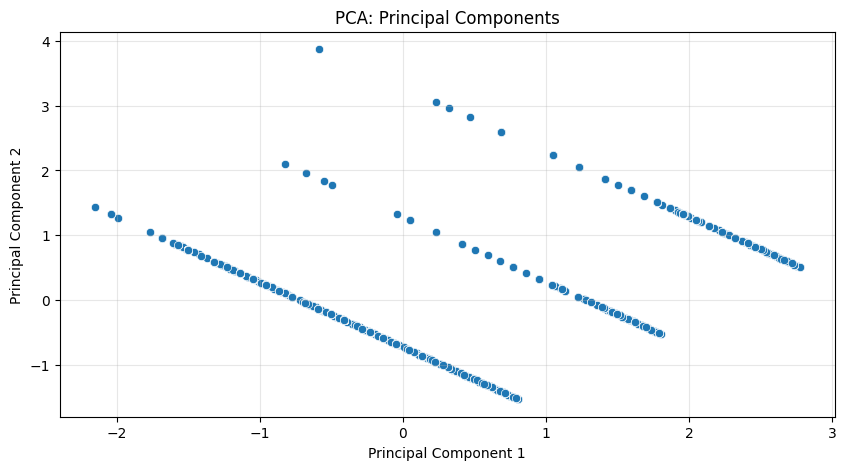

In [23]:
df_components = pd.DataFrame(components, columns=['PC1', 'PC2'])

plt.figure(figsize=FIGSIZE)
sns.scatterplot(data=df_components, x='PC1', y='PC2')

ax = plt.gca()
# ax.xaxis.set_major_formatter(FORMATTER)
ax.grid(alpha=0.3)
# ax.legend()

x_label, y_label = 'Principal Component 1', 'Principal Component 2'
title = 'PCA: Principal Components'

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
# plt.tight_layout()

Se observan las contribuciones de los componentes 1 y 2:
- PC 1: La mayoría de los puntos indica contribuciones *negativas* a los valores originales
- PC 2: La mayoría de los puntos indica contribuciones *positivas* a los valores originales
- Se pueden observar formaciones de *clusters*, o subgrupos que indican patrones
- Por lo anterior se observa correlación


Para poder ver la varianza capturada podemos usar la funcion explained_variance_ratio_ de la instancia de PCA que creamos anteriormente.

Text(0.5, 1.0, 'PCA: Variance')

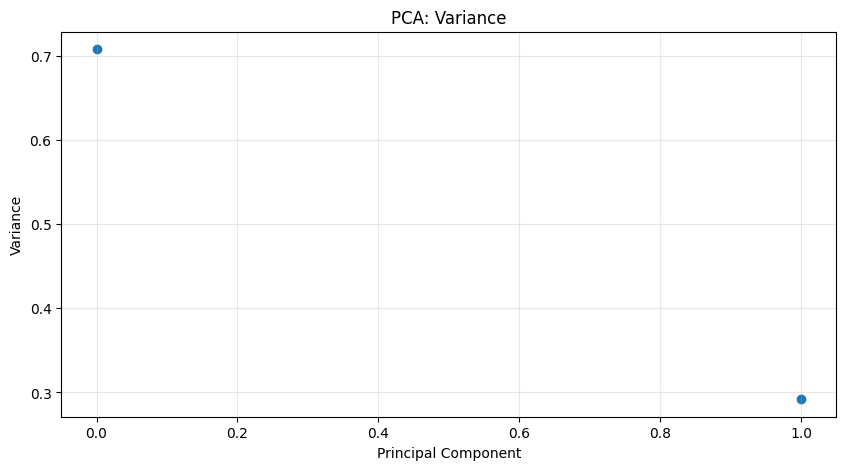

In [24]:
plt.figure(figsize=FIGSIZE)
plt.scatter(range(len(pca.explained_variance_)), pca.explained_variance_ratio_)

ax = plt.gca()
ax.grid(alpha=0.3)

x_label, y_label = 'Principal Component', 'Variance'
title = 'PCA: Variance'

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)

Esto nos esta diciendo que el 70% de la varianza esta representada por la variable `Type`, mientas que el otro 30% de la varianza esta representada por la variable `YearBuild`.

# !!!Atencion, aqui termina toda mi contribucion. el resto no fue tocado. ¡¡¡

## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
> El método `get_feature_names` **NO EXISTE**  
> - para empezar un método lleva paréntesis  
> - además el método es get_feature_names_out()  
> el atributo `categories_` no retorna las originales, sino las resultantes del encoding
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.
> ¿Esto es una consigna? ¿Qué es?

Dado que se cuenta con la columna original `Types` y que lo propuesto en el inciso 1 *no tiene sentido*, se realiza un join del dataframe original, se reemplaza la columna `YearBuilt` imputada.

In [25]:
df.loc[:, 'YearBuilt'] = X.YearBuilt.astype(int)
df.sample(15).style.format(
    {'Price': human_format,
     'NeighborhoodOverview': lambda x: x[:50]},
    precision=1,
    na_rep='missing'
    ).highlight_null(color='gray'
    ).bar(subset=['Price'], color='green'
    ).bar(subset=['BuildingRatio'], color='brown')

/tmp/ipykernel_10799/4101846874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'YearBuilt'] = X.YearBuilt.astype(int)


,Propertycount,Type,NeighborhoodOverview,Suburb,Bedroom2,Distance,Car,Price,Rooms,State,BuildingRatio,Neighborhood,ZipCode,City,SmartLocation,Address,YearBuilt
1200,11204,t,This hip area is a crossroads between two great cu,Coburg,3,7.8,1,810K,3,VIC,1.6,Brunswick,3058.0,Moreland,"Coburg, Australia",2/44 Berry St,2010
3184,13240,u,A stay at our apartment means you can enjoy some o,St Kilda,3,6.1,1,2M,3,VIC,9.5,St Kilda,3182.0,Port Phillip,"St Kilda, Australia",3/33 Robe St,1920
183,3052,h,Our local parks and gardens provide lovely walks a,Ashburton,3,11.0,2,1M,3,VIC,1.6,Ashburton,3147.0,Boroondara,"Ashburton, Australia",16a Nicholas St,2004
862,4480,h,Very safe! Family oriented. Older age group.; Very,Bulleen,4,11.8,1,1M,4,VIC,5.0,Balwyn North,3105.0,Manningham,"Bulleen, Australia",135 Manningham Rd,1960
984,3265,h,Our house is perfectly located for you to enjoy an,Canterbury,3,9.0,2,2M,3,VIC,3.2,Hawthorn,3126.0,Boroondara,"Canterbury, Australia",42 Warburton Rd,1890
2720,7717,h,The suburb of Prahran is located south east of the,Prahran,2,4.6,0,780K,2,VIC,2.4,Windsor,3181.0,Stonnington,"Prahran, Australia",20 King St,1900
3047,14949,h,"Bridge Road (once famous for discount shopping, no",Richmond,2,2.6,0,1M,2,VIC,1.4,Richmond,3121.0,Yarra,"Richmond, Australia",24 The Crofts,1900
824,7082,h,This hip area is a crossroads between two great cu,Brunswick West,3,5.9,1,1M,4,VIC,4.0,Brunswick,3055.0,Moreland,"Brunswick West, Australia",15 Wallace St,1935
1342,4898,h,"Fabulous Caulfield Park, Glenferrie Rd, High S. an",Elsternwick,4,8.5,1,1M,4,VIC,3.3,Caulfield,3185.0,Glen Eira,"Elsternwick, Australia",44 Hartington St,1910
1151,11204,h,This hip area is a crossroads between two great cu,Coburg,3,7.8,2,1M,3,VIC,3.0,Brunswick,3058.0,Moreland,"Coburg, Australia",3 Mavis St,1940


In [26]:
df.YearBuilt

0       1900
1       1890
2       2005
3       1890
4       1880
        ... 
3858    1945
3859    1960
3860    2012
3861    1950
3862    1940
Name: YearBuilt, Length: 3863, dtype: int64

In [27]:
df_to_plot = df.YearBuilt
x_label, y_label, title = 'freq', 'housing imputed year built', 'freq'
n_bins = 30

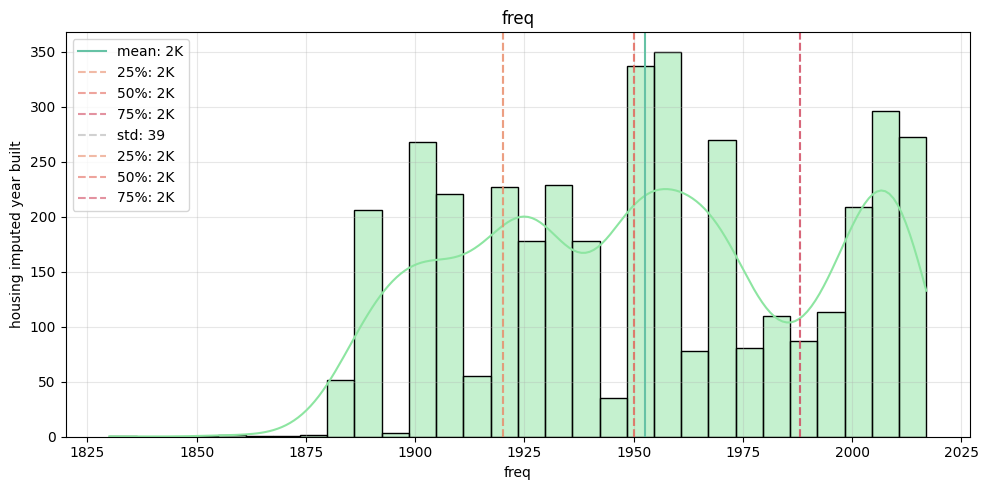

In [28]:
f, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=DPI, sharex=True)

sns.histplot(df_to_plot,
             bins=n_bins,
             color=next(MAIN_PALETTE),
             kde=True)

ax = plt.gca()
ax.figsize=FIGSIZE

statistics = df_to_plot.describe(include='all')

for j, name in enumerate(['mean', 'std']):
    linestyle = 'solid' if name == 'mean' else 'dashed'
    alpha = 1 if name == 'mean' else .6

    statistic = statistics[name]

    ax.axvline(statistic,
              label=f'{name}: {human_format(statistic)}',
              color=CATEGORICAL_PALETTE.as_hex()[-j],
              linestyle=linestyle,
              alpha=alpha)

    for j, st in enumerate(['25%', '50%', '75%']):
        statistic = statistics[st]
        ax.axvline(statistic,
                  label=f'{st}: {human_format(statistic)}',
                  color=SECUENTIAL_PALETTE.as_hex()[j],
                  linestyle='dashed',
                  alpha=.6,)

    # ax.xaxis.set_major_formatter(FORMATTER)
    ax.grid(alpha=0.3)
    ax.legend()

plt.xlim(statistics['min'] - 10, statistics['max'] + 10)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.tight_layout()

In [29]:
df.to_csv('data/melbourne_housing_inputed_data.csv', index=False)

## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más 
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de 
     publicaciones de la plataforma AirBnB en el mismo código 
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el 
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
